# Использование Open CV для измерения размера объектов на изображении

In [ ]:
import cv2 # импорт Open CV
import numpy as np
from scipy.spatial import distance as dist
from imutils import perspective
from imutils import contours
from PIL import Image
import imutils
import matplotlib.pyplot as plt

%matplotlib inline

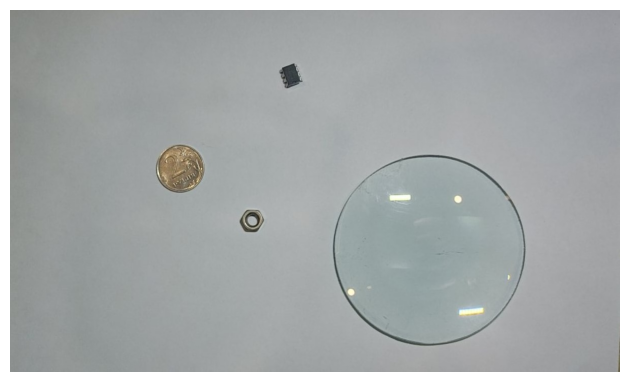

In [51]:
image = np.array(Image.open('Фото1.jpg')) # считываем данные графического файла в переменную image
plt.axis('off')
plt.tight_layout()
plt.imshow(image)

In [ ]:
def midpoint(ptA, ptB): # функция вычисления средней точки
   return ((ptA[0] + ptB[0]) * 0.5, (ptA[1] + ptB[1]) * 0.5)

In [56]:
def objects_size(image_rgb, reference_width, canny_treshold=(50, 70), object_treshold=1000, sort_method='lest-to-right', font_scale=0.65):
    plt.figure(figsize=(21, 25), dpi=90)
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY) # преобразование в градации серого
    gray = cv2.GaussianBlur(gray, (3, 3), 0) # фильтр Гаусса с маской 3х3. Отсутствие размытия зачастую дает детекцию ложных объектов
    plt.subplot(3,1,1); plt.imshow(gray, cmap='gray'); plt.axis('off'); plt.title('Grayscale размытое изображение')
    
    edged = cv2.Canny(gray, *canny_treshold) # обнаруживаем края
    edged = cv2.erode(cv2.dilate(edged, None, iterations=2), None, iterations=1) # выполняем дилатацию и эрозию, чтобы  получить четкие края
    plt.subplot(3,1,2); plt.imshow(edged, cmap='gray'); plt.axis('off'); plt.title('Края изображения')

    # RETR_EXTERNAL - находит только внешние контуры, CV_CHAIN_APPROX_SIMPLE - склеивает все горизонтальные, вертикальные и диагональные контуры
    cnts = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    (cnts, _) = contours.sort_contours(cnts, method=sort_method) # сортируем найденные контуры в нужном порядке

    orig = image.copy()
    pixelsPerMillimetr = None
    for c in cnts:
        if cv2.contourArea(c) < object_treshold: # пропускаем маленькие контуры
            continue
        box = cv2.minAreaRect(c) # вычисляем рамку ограничивающую контур
        box = cv2.cv.BoxPoints(box) if imutils.is_cv2() else cv2.boxPoints(box) # определяем углы
        box = perspective.order_points(box) # сортируем координаты по часовой стрелке
        cv2.drawContours(orig, [box.astype("int")], -1, (0, 255, 0), 2) # рисуем рамку, openCV  оперирует палитрой BGR

        # 4 средних точки габаритной рамки
        (tl, tr, br, bl) = box
        (tltrX, tltrY) = midpoint(tl, tr)
        (blbrX, blbrY) = midpoint(bl, br)
        (tlblX, tlblY) = midpoint(tl, bl)
        (trbrX, trbrY) = midpoint(tr, br)

        # средние линии синим цветом
        cv2.line(orig, (int(tltrX), int(tltrY)), (int(blbrX), int(blbrY)), (0, 0, 255), 2)
        cv2.line(orig, (int(tlblX), int(tlblY)), (int(trbrX), int(trbrY)), (0, 0, 255), 2)

        dA = dist.euclidean((tltrX, tltrY), (blbrX, blbrY))
        dB = dist.euclidean((tlblX, tlblY), (trbrX, trbrY))

        # Если переменная pixelsPerMillimetr неопределена, значит идет вычисление
        # самого левого объекта, который является эталонным и его размер известен
        if pixelsPerMillimetr is None:
            pixelsPerMillimetr = dB / reference_width

            cv2.putText(orig, "reference object",
            (int(tltrX - 70), int(tltrY - 40)), cv2.FONT_HERSHEY_SIMPLEX,
            0.65, (255, 255, 255), 2)


        # вычисляем  размер пикселя
        dimA = dA / pixelsPerMillimetr
        dimB = dB / pixelsPerMillimetr

        # наносим размер объекта на изображение
        cv2.putText(orig, "{:.1f}mm".format(dimB),
            (int(tltrX - 15), int(tltrY - 10)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), 2)

        cv2.putText(orig, "{:.1f}mm".format(dimA),
            (int(trbrX + 10), int(trbrY)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), 2)

        #  выводим размер пикселя
        cv2.putText(orig, "Pixel size: {:.1f} mm".format(1/pixelsPerMillimetr),(20, 20), cv2.FONT_HERSHEY_SIMPLEX,
            font_scale, (255, 255, 255), 2)

    plt.subplot(3,1,3); plt.imshow(orig, cmap='gray'); plt.axis('off'); plt.title('Размеры объектов')
    plt.tight_layout()
    plt.show()

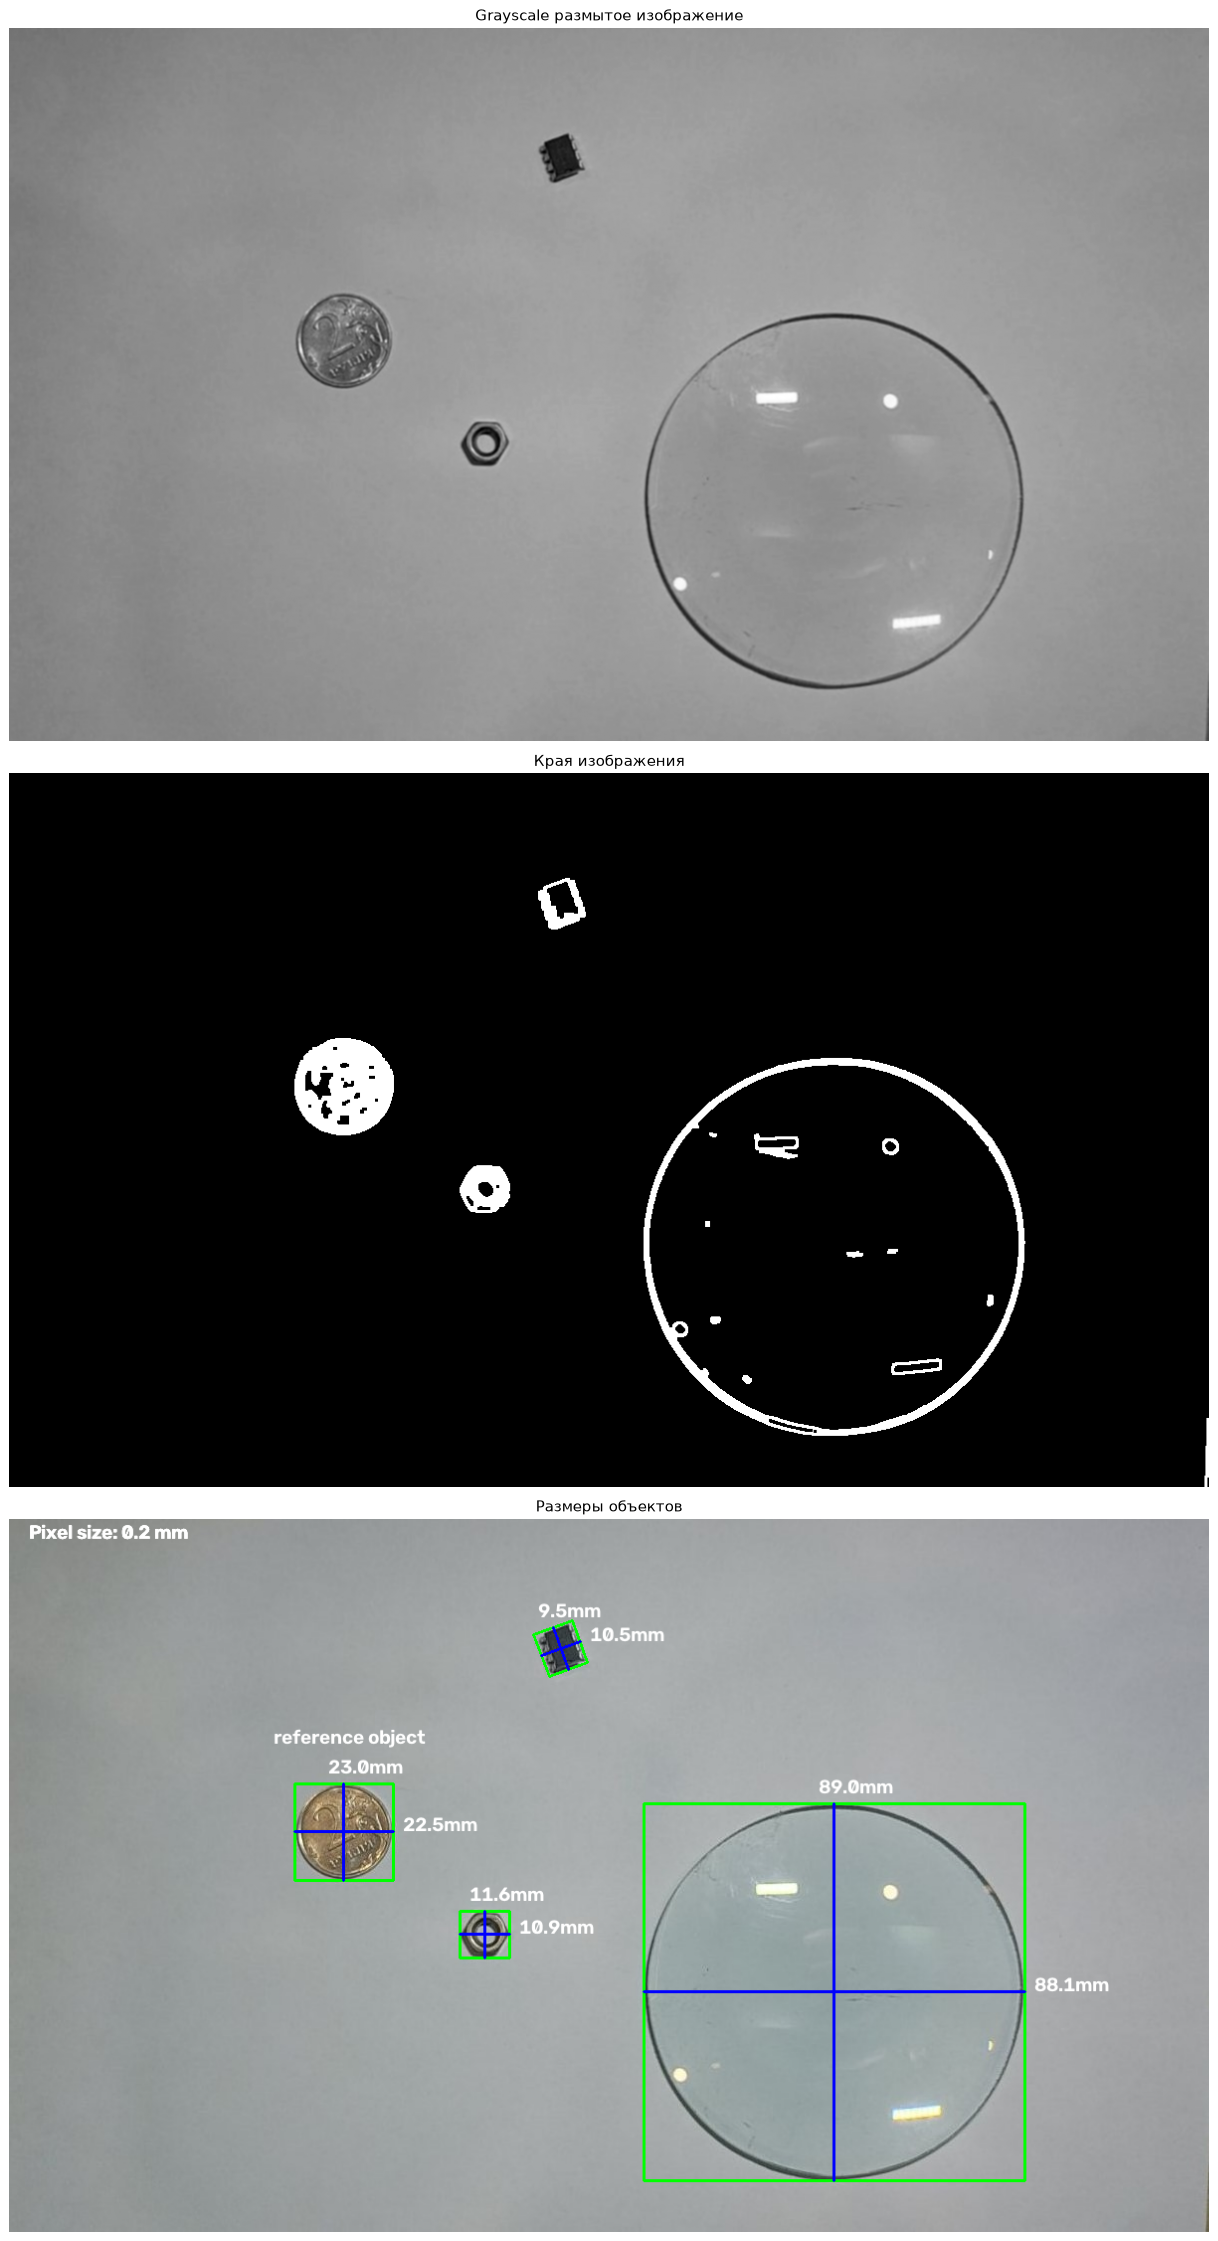

In [53]:
objects_size(image, reference_width=23)

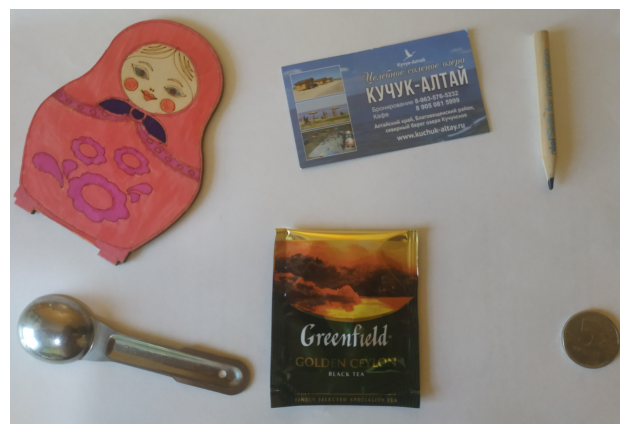

In [54]:
image = np.array(Image.open('Фото2.jpg')) # считываем данные графического файла в переменную image
plt.axis('off')
plt.tight_layout()
plt.imshow(image)

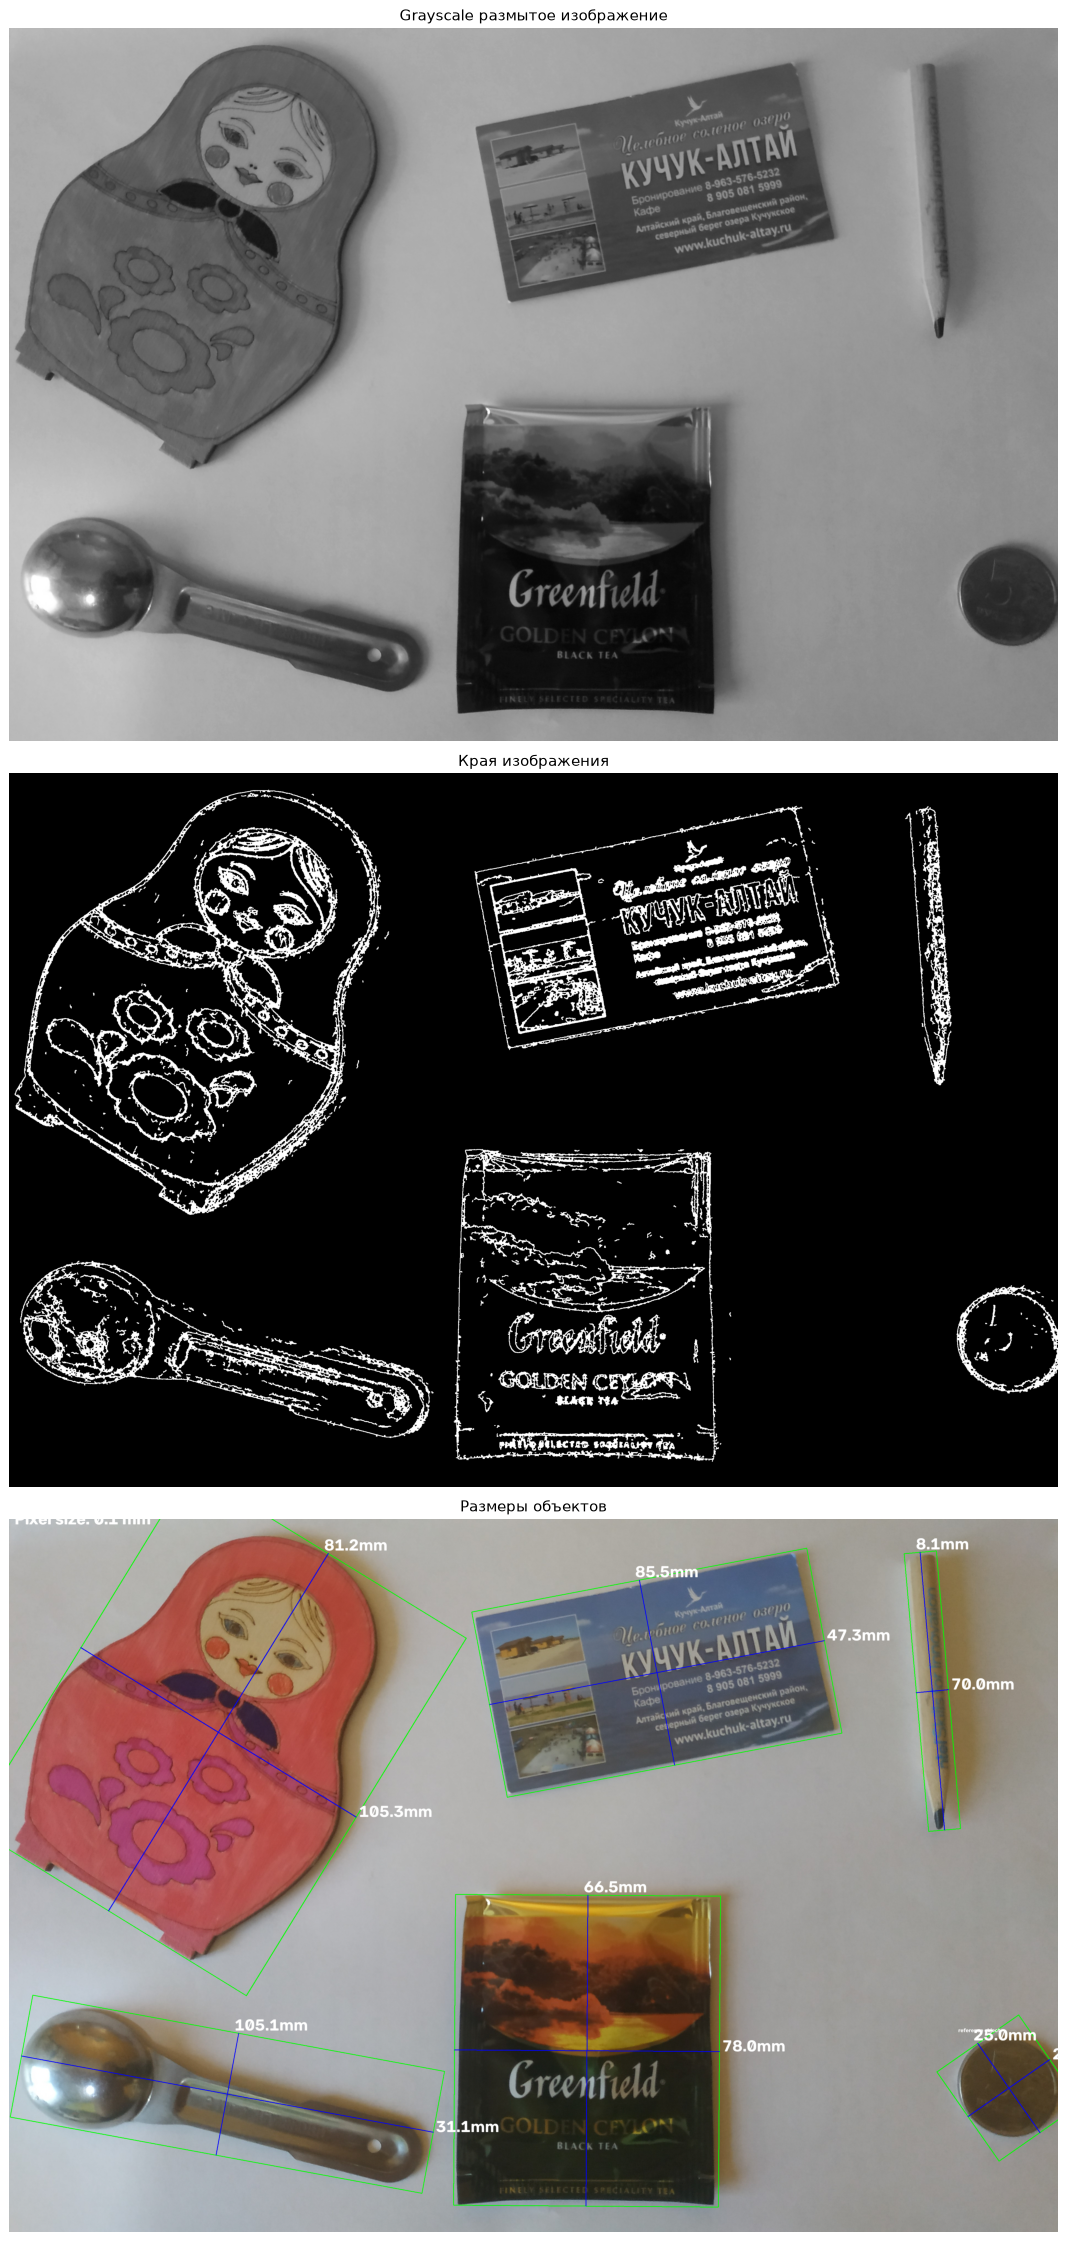

In [58]:
objects_size(image, reference_width=25, canny_treshold=(15, 29), object_treshold=25000, sort_method='right-to-left', font_scale=2)